# Classification using Tensorflow

In [1]:
import tensorflow as tf

In [2]:
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)

import pandas as pd
circles = pd.DataFrame({"X0": X[:, 0], "X1": X[:, 1], "label": y})

circles

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


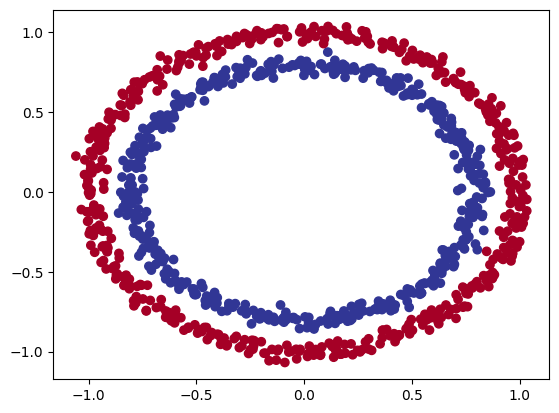

In [3]:
from matplotlib.colors import Colormap
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [4]:
## Building a Model
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

history = model.fit(X, y, epochs=100, verbose=0)

In [5]:
# Creating Model 1 Traning for longer
model.fit(X, y, epochs=200, verbose=0)
model.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4860 - loss: 0.6933


[0.6932877898216248, 0.4860000014305115]

In [6]:
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

history_1 = model_1.fit(X, y, epochs=100, verbose=0)
model_1.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4920 - loss: 0.6970


[0.697045087814331, 0.492000013589859]

In [7]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1)
])

model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=['accuracy'])

history_2 = model_2.fit(X, y, epochs=100, verbose=0)
model_2.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9990 - loss: 0.0149


[0.014938742853701115, 0.9990000128746033]

In [8]:
# Function to visualize the decision boundary of a trained model
def plot_decision_boundary(model, X, y):
  import numpy as np
  import matplotlib.pyplot as plt
  import tensorflow as tf # Import tensorflow for tf.squeeze if not already imported globally

  # Define the axis boundaries of the plot based on the input data X
  # We add a small margin (0.1) to ensure all data points are visible.
  x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
  y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

  # Create a meshgrid: This generates a grid of points (xx, yy) over the entire plot area.
  # The model will make predictions for each of these points to draw the decision boundary.
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                      np.linspace(y_min, y_max, 100))

  # Prepare input for the model: This converts the 2D grid points into a flat array of (x, y) coordinates.
  # Fix 1: The original code `np.c_[[xx.ravel(), yy.ravel()]]` created a shape (2, 10000)
  # (2 samples, 10000 features each). The model expects (number_of_samples, number_of_features),
  # so it should be (10000, 2). Removing the outer list `[]` corrects this.
  x_in = np.c_[xx.ravel(), yy.ravel()]

  # Make predictions on the grid points using the provided model.
  y_pred = model.predict(x_in)

  # Process predictions to get class labels and reshape them back to the grid shape.
  # This is crucial for plotting the decision regions.
  if y_pred.shape[-1] == 1: # This condition typically indicates binary classification (single output neuron)
    # For binary classification, model.predict often outputs probabilities (e.g., between 0 and 1).
    # We convert these probabilities to class labels (0 or 1) by applying a threshold (e.g., 0.5).
    # tf.squeeze removes single-dimensional entries from the shape of an array.
    p_pred = (tf.squeeze(y_pred) > 0.5).numpy().reshape(xx.shape)
  else: # This condition handles multi-class classification (multiple output neurons with softmax)
    # In multi-class, we take the index of the highest probability as the predicted class.
    print("doing multiclass classification") # Original print statement kept for context
    p_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)

  # Plot the decision boundary.
  # Fix 2: Typo - `plt.countourf` should be `plt.contourf`.
  # Fix 3: The third argument to `contourf` should be `p_pred` (the model's predictions on the grid),
  # not `y` (the original true labels). Plotting `y` would show contours based on the original data distribution,
  # not the model's learned decision regions.
  plt.contourf(xx, yy, p_pred, cmap=plt.cm.RdYlBu, alpha=0.7)

  # Plot the original data points on top of the decision boundary.
  # `c=y` colors the points according to their true labels.
  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)

  # Set plot limits to match the meshgrid boundaries.
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

  # Display the plot.
  plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


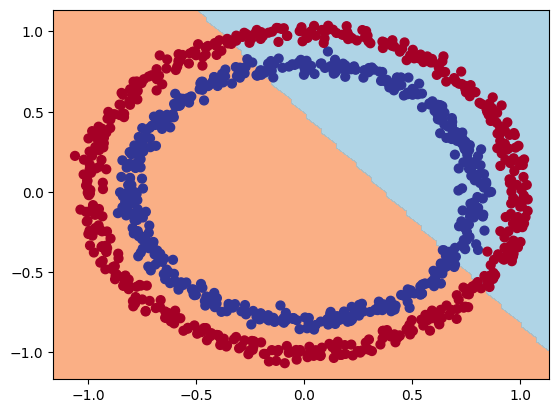

In [9]:
plot_decision_boundary(model, X, y)

## Introduction to non-linearity


In [10]:
tf.random.set_seed(42)

model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.linear),
])

model_4.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

history_4 = model_4.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4620 - loss: 4.5263
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4650 - loss: 4.3916
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4640 - loss: 4.3377
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4650 - loss: 4.2955
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4680 - loss: 4.2690
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4700 - loss: 4.2294
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4710 - loss: 4.1987
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4700 - loss: 4.1795
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4700 - loss: 4.1526
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4690 - loss: 4.0924
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4700 - loss: 4.0224
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


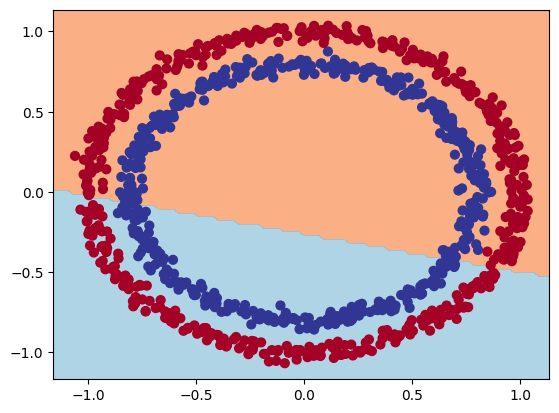

In [11]:
plot_decision_boundary(model_4, X, y)

In [12]:
tf.random.set_seed(42)

model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.relu)
])

model_5.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

history_5 = model_5.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4830 - loss: 5.9590
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4820 - loss: 5.8987
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 5.8341
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4840 - loss: 5.8172
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4820 - loss: 5.7746
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4820 - loss: 5.7272
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4800 - loss: 5.7008
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4810 - loss: 5.6958
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4810 - loss: 5.6924
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4810 - loss: 5.6809
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4810 - loss: 5.6657
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

In [13]:
model_5.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4770 - loss: 4.3582


[4.358170509338379, 0.47699999809265137]

In [14]:
tf.random.set_seed(42)

model_6 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1)
])


model_6.compile(loss='binary_crossentropy',
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['accuracy'])

history_6 = model_6.fit(X, y, epochs=200, verbose=0)

The important of activation in the output layer? and also in other layers? and what are the activations to use?

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9960 - loss: 0.0183  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


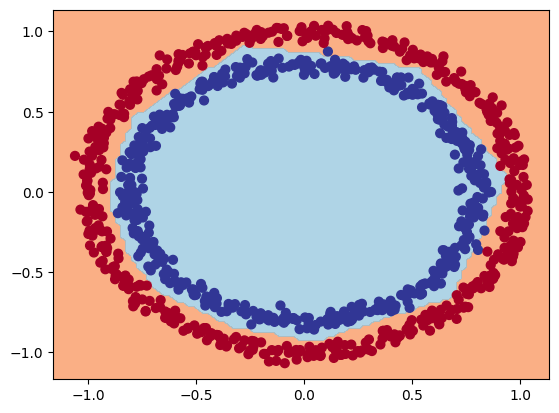

In [15]:
model_6.evaluate(X, y)

plot_decision_boundary(model_6, X, y)

In [16]:
tf.random.set_seed(42)

model_7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1, activation=tf.keras.activations.sigmoid)
])

model_7.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['accuracy']) # Changed tf.keras.metrics.Accuracy() to 'accuracy'

history_7 = model_7.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5030 - loss: 0.6946
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5280 - loss: 0.6904
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5370 - loss: 0.6878
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5400 - loss: 0.6860
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5410 - loss: 0.6847
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5460 - loss: 0.6837
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5470 - loss: 0.6827
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5510 - loss: 0.6818
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5580 - loss: 0.6809
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5620 - loss: 0.6800
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5570 - loss: 0.6792
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9980 - loss: 0.1604  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


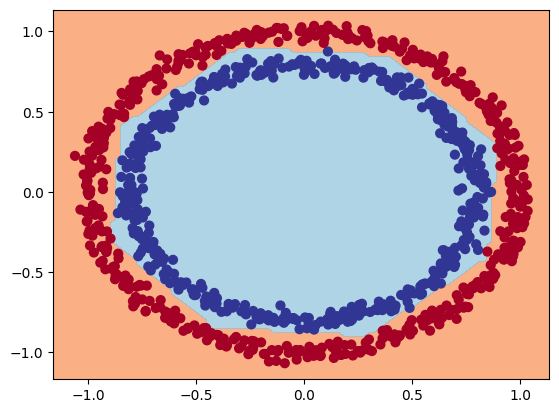

In [17]:
model_7.evaluate(X, y)

plot_decision_boundary(model_7, X, y)

The combination of linear and non-linear functions is one of the key fundamentals of neural network. IN the Relu and Sigmoid note, transform a normal tensor vector into relu and plot?

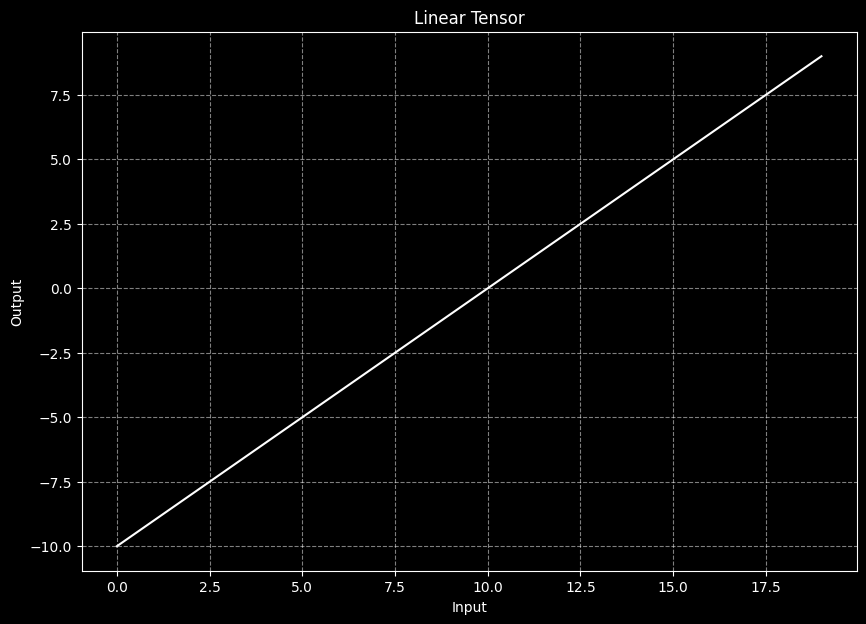

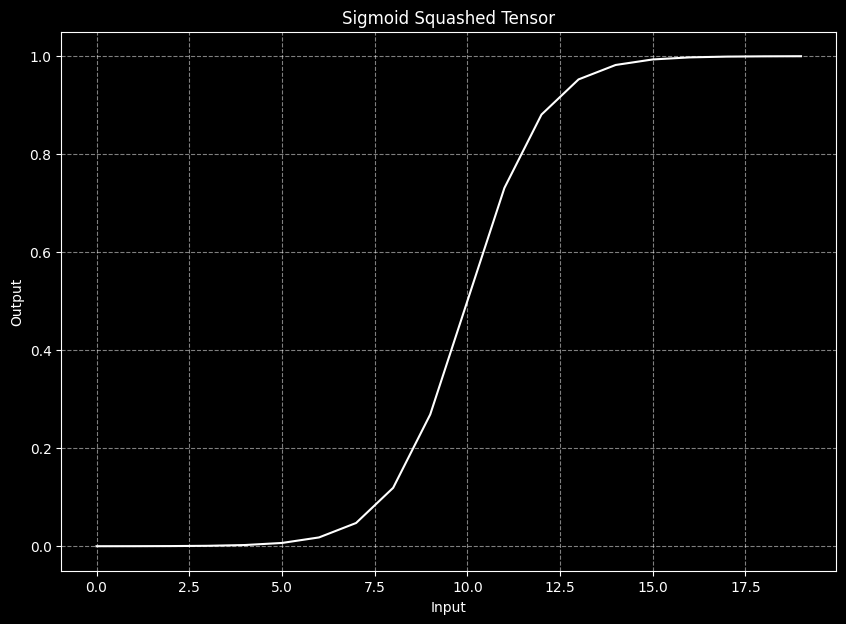

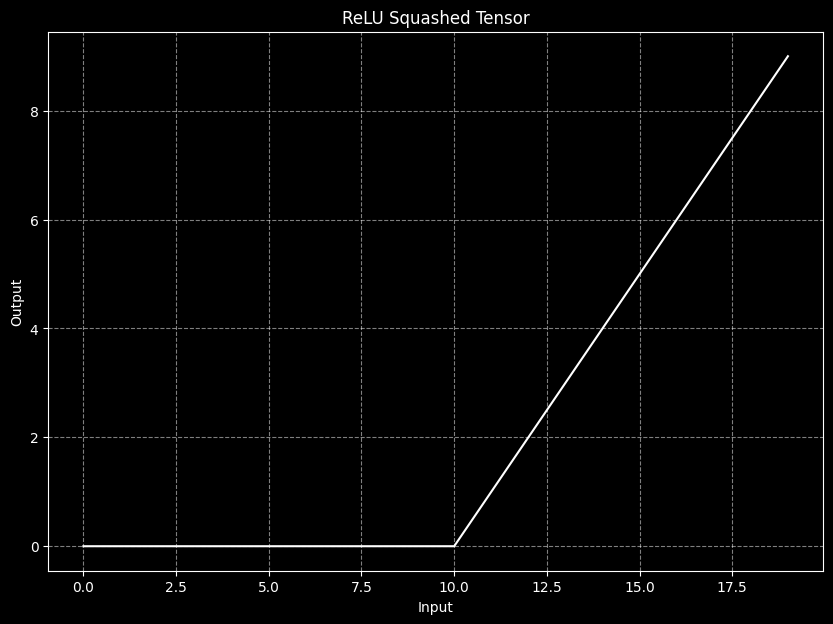

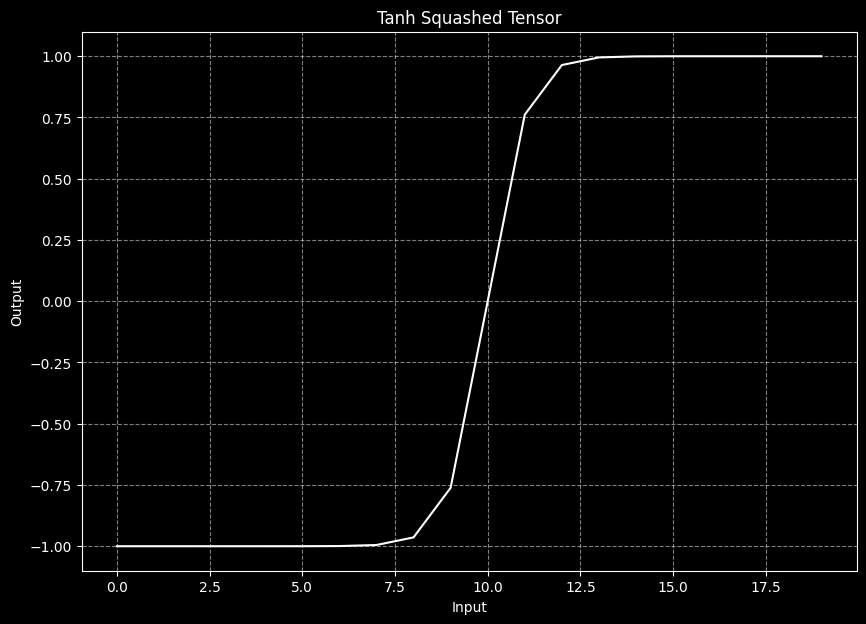

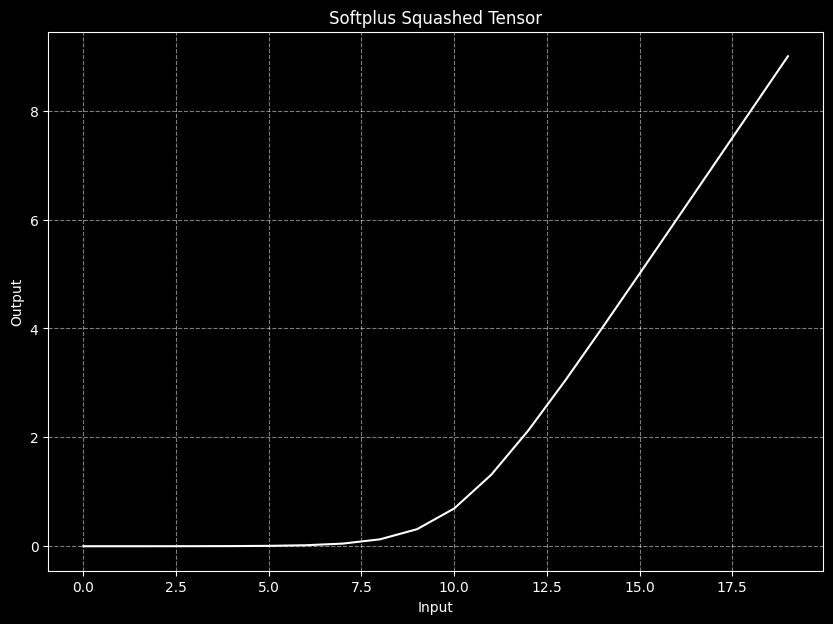

In [18]:
import matplotlib.pyplot as plt
import tensorflow as tf # Ensure tf is imported for activation functions

linear_line = tf.cast(tf.range(-10, 10), tf.float32)

# Plot Linear Tensor
fig_linear = plt.figure(figsize=(10, 7), facecolor='black')
ax_linear = fig_linear.add_subplot(111)
ax_linear.set_facecolor('black') # Set axes background to black
ax_linear.plot(linear_line, color='white')
ax_linear.set_title("Linear Tensor", color='white')
ax_linear.set_xlabel("Input", color='white')
ax_linear.set_ylabel("Output", color='white')
ax_linear.tick_params(axis='x', colors='white')
ax_linear.tick_params(axis='y', colors='white')
ax_linear.spines['bottom'].set_color('white') # Set x-axis line color
ax_linear.spines['top'].set_color('white')    # Set top spine color
ax_linear.spines['left'].set_color('white')   # Set y-axis line color
ax_linear.spines['right'].set_color('white')  # Set right spine color
ax_linear.grid(True, color='white', linestyle='--', alpha=0.5) # Add white grid
plt.savefig("linear.png", facecolor='black') # Save with black background
plt.show()
plt.close(fig_linear) # Close the figure to ensure separate display and free memory

# Create a sigmoid squashing of the tensor
sigmoid = tf.math.sigmoid(linear_line)
fig_sigmoid = plt.figure(figsize=(10, 7), facecolor='black')
ax_sigmoid = fig_sigmoid.add_subplot(111)
ax_sigmoid.set_facecolor('black')
ax_sigmoid.plot(sigmoid, color='white')
ax_sigmoid.set_title("Sigmoid Squashed Tensor", color='white')
ax_sigmoid.set_xlabel("Input", color='white')
ax_sigmoid.set_ylabel("Output", color='white')
ax_sigmoid.tick_params(axis='x', colors='white')
ax_sigmoid.tick_params(axis='y', colors='white')
ax_sigmoid.spines['bottom'].set_color('white')
ax_sigmoid.spines['top'].set_color('white')
ax_sigmoid.spines['left'].set_color('white')
ax_sigmoid.spines['right'].set_color('white')
ax_sigmoid.grid(True, color='white', linestyle='--', alpha=0.5)
plt.savefig("sigmoid.png", facecolor='black')
plt.show()
plt.close(fig_sigmoid)

# Create ReLU squashing of the tensor
relu = tf.math.maximum(0, linear_line)
fig_relu = plt.figure(figsize=(10, 7), facecolor='black')
ax_relu = fig_relu.add_subplot(111)
ax_relu.set_facecolor('black')
ax_relu.plot(relu, color='white')
ax_relu.set_title("ReLU Squashed Tensor", color='white')
ax_relu.set_xlabel("Input", color='white')
ax_relu.set_ylabel("Output", color='white')
ax_relu.tick_params(axis='x', colors='white')
ax_relu.tick_params(axis='y', colors='white')
ax_relu.spines['bottom'].set_color('white')
ax_relu.spines['top'].set_color('white')
ax_relu.spines['left'].set_color('white')
ax_relu.spines['right'].set_color('white')
ax_relu.grid(True, color='white', linestyle='--', alpha=0.5)
plt.savefig("relu.png", facecolor='black')
plt.show()
plt.close(fig_relu)

# Create Tanh squashing of the tensor
tanh = tf.math.tanh(linear_line)
fig_tanh = plt.figure(figsize=(10, 7), facecolor='black')
ax_tanh = fig_tanh.add_subplot(111)
ax_tanh.set_facecolor('black')
ax_tanh.plot(tanh, color='white')
ax_tanh.set_title("Tanh Squashed Tensor", color='white')
ax_tanh.set_xlabel("Input", color='white')
ax_tanh.set_ylabel("Output", color='white')
ax_tanh.tick_params(axis='x', colors='white')
ax_tanh.tick_params(axis='y', colors='white')
ax_tanh.spines['bottom'].set_color('white')
ax_tanh.spines['top'].set_color('white')
ax_tanh.spines['left'].set_color('white')
ax_tanh.spines['right'].set_color('white')
ax_tanh.grid(True, color='white', linestyle='--', alpha=0.5)
plt.savefig("tanh.png", facecolor='black')
plt.show()
plt.close(fig_tanh)

# Create Softplus squashing of the tensor
softplus = tf.math.softplus(linear_line)
fig_softplus = plt.figure(figsize=(10, 7), facecolor='black')
ax_softplus = fig_softplus.add_subplot(111)
ax_softplus.set_facecolor('black')
ax_softplus.plot(softplus, color='white')
ax_softplus.set_title("Softplus Squashed Tensor", color='white')
ax_softplus.set_xlabel("Input", color='white')
ax_softplus.set_ylabel("Output", color='white')
ax_softplus.tick_params(axis='x', colors='white')
ax_softplus.tick_params(axis='y', colors='white')
ax_softplus.spines['bottom'].set_color('white')
ax_softplus.spines['top'].set_color('white')
ax_softplus.spines['left'].set_color('white')
ax_softplus.spines['right'].set_color('white')
ax_softplus.grid(True, color='white', linestyle='--', alpha=0.5)
plt.savefig("softplus.png", facecolor='black')
plt.show()
plt.close(fig_softplus)

In [19]:
## Evaluating and improving our classification

len(X)

1000

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((750, 2), (250, 2), (750,), (250,))

What is learning rate and how it actually improves a mdoels learning?

In [21]:
# Training and Testing

tf.random.set_seed(42)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="accuracy",
    patience=10,
    restore_best_weights=True
)

final_model = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1, activation=tf.keras.activations.sigmoid)
])

final_model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                    metrics=['accuracy'])

final_history = final_model.fit(X_train, y_train, epochs=200, callbacks=[early_stopping])

Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5027 - loss: 0.7102
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4613 - loss: 0.6926 
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 0.6851
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5253 - loss: 0.6786 
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5320 - loss: 0.6707 
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5573 - loss: 0.6591 
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6240 - loss: 0.6452 
Epoch 8/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6280 - loss: 0.6321 
Epoch 9/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6480 - loss: 0.6189 
Epoch 10/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6680 - loss: 0.6035
Epoch 11/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6960 - loss: 0.5849
Epoch 12/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - ac

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9800 - loss: 0.0626  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


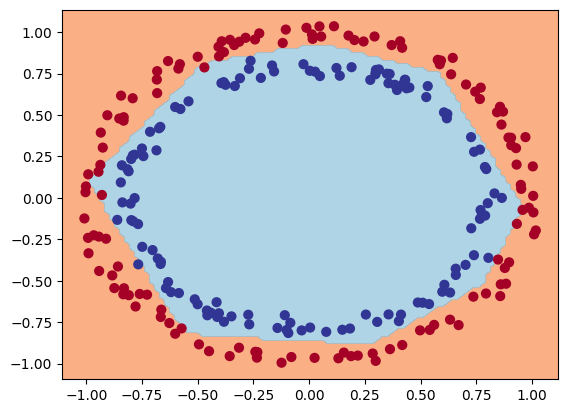

In [22]:
final_model.evaluate(X_test, y_test)
plot_decision_boundary(final_model, X_test, y_test)

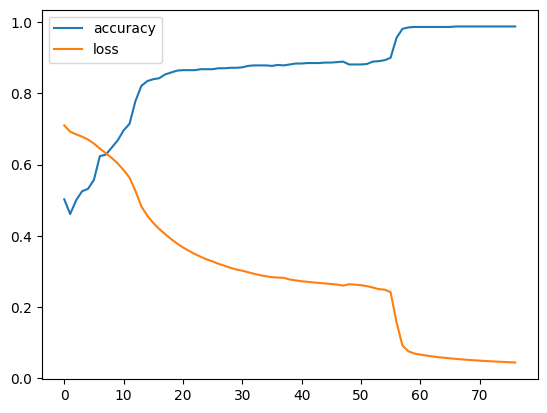

In [23]:
# Printing Loss Curvs
pd.DataFrame(final_history.history).plot()
plt.show()


In [24]:
# Callbacks and learning rate vs loss decrease

tf.random.set_seed(42)

model_9 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_9.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))

history_9 = model_9.fit(X_train, y_train, epochs=100, callbacks=[lr_scheduler])


Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4907 - loss: 0.6932 - learning_rate: 1.0000e-04
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4907 - loss: 0.6932 - learning_rate: 1.1220e-04
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4920 - loss: 0.6932 - learning_rate: 1.2589e-04
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4973 - loss: 0.6931 - learning_rate: 1.4125e-04
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4973 - loss: 0.6931 - learning_rate: 1.5849e-04
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4973 - loss: 0.6931 - learning_rate: 1.7783e-04
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4960 - loss: 0.6931 - learning_rate: 1.9953e-04
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4960 - loss: 0.6931 - learning_rate: 2.2387e-04
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4960 - loss: 0.6931 - learning_

<Axes: >

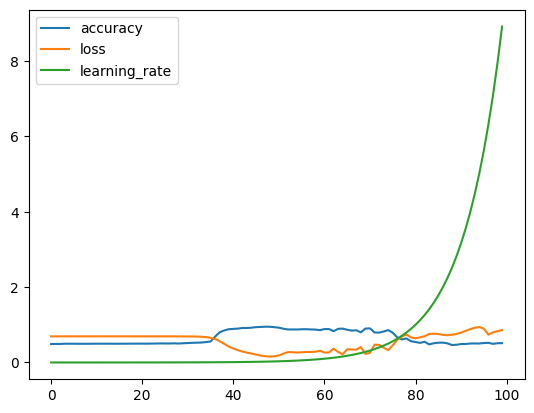

In [25]:
pd.DataFrame(history_9.history).plot()

In [26]:
model_9.evaluate(X_test, y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5160 - loss: 0.8220  


[0.8219841122627258, 0.515999972820282]

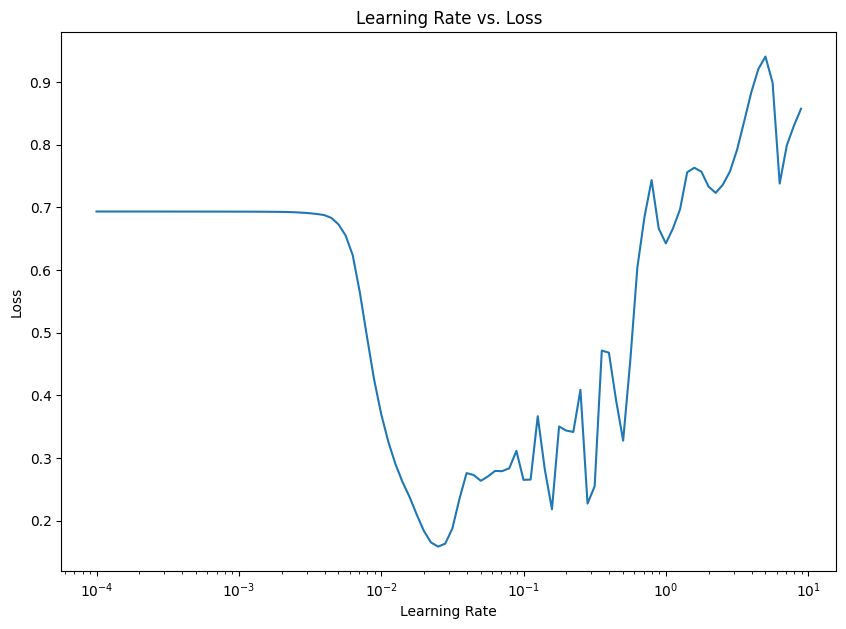

In [27]:
# plot the learning rate versus the loss
lrs = 1e-4 * (10 ** (tf.range(100)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history_9.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning Rate vs. Loss")
plt.show()


Finding the ideal learning rate from the loss curve. The ideal learning rate is when the loss is still decreasing but it hasen't platued.

In [28]:
tf.random.set_seed(42)

model_10 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_10.compile(loss="binary_crossentropy",
                 optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
                 metrics=["accuracy"])

model_10.fit(X_train, y_train, epochs=40)

Epoch 1/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4653 - loss: 0.7033
Epoch 2/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5040 - loss: 0.6914 
Epoch 3/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5347 - loss: 0.6866 
Epoch 4/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5613 - loss: 0.6808 
Epoch 5/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5640 - loss: 0.6686
Epoch 6/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6133 - loss: 0.6455 
Epoch 7/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6520 - loss: 0.6198 
Epoch 8/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6733 - loss: 0.5886 
Epoch 9/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7093 - loss: 0.5461 
Epoch 10/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7173 - loss: 0.5039
Epoch 11/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7560 - loss: 0.4711 
Epoch 12/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8000 - loss: 0.3772  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


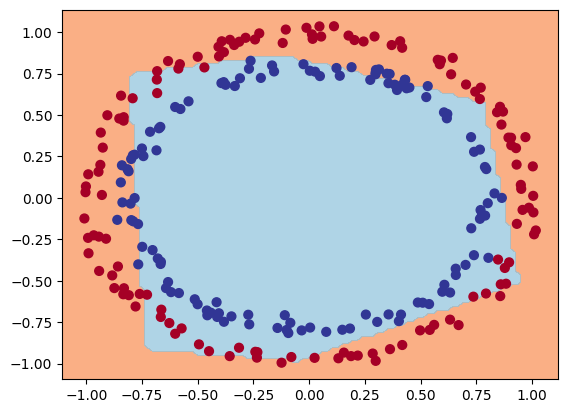

In [29]:
model_10.evaluate(X_test, y_test)
plot_decision_boundary(model_10, X_test, y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


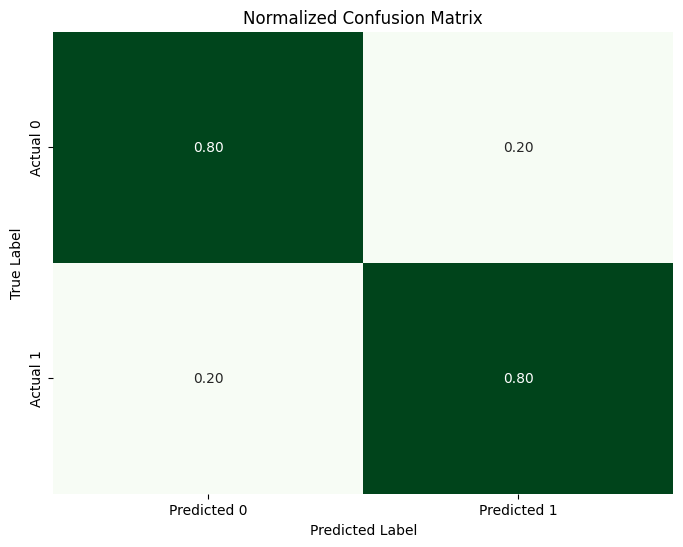

In [30]:
## More classification Evaluation Metrices

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_curve, confusion_matrix

y_pred = model_10.predict(X_test)
y_pred = tf.squeeze(tf.round(y_pred))

cm = confusion_matrix(y_test, y_pred, normalize='true')

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Greens', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Wroking with a larger example

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(train_data, train_lables), (test_data, test_lables) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
train_data[0].shape, train_lables[0].shape

((28, 28), ())

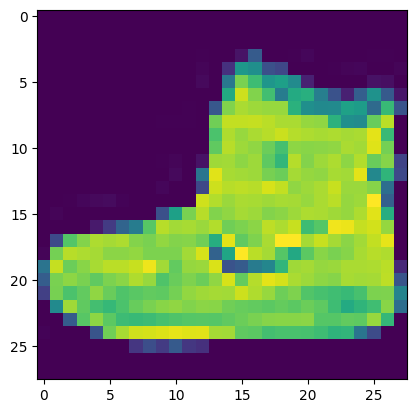

In [3]:
import matplotlib.pyplot as plt
plt.imshow(train_data[0])

In [4]:
rng = tf.random.Generator.from_seed(42)

tf.Tensor(51303, shape=(), dtype=int32)


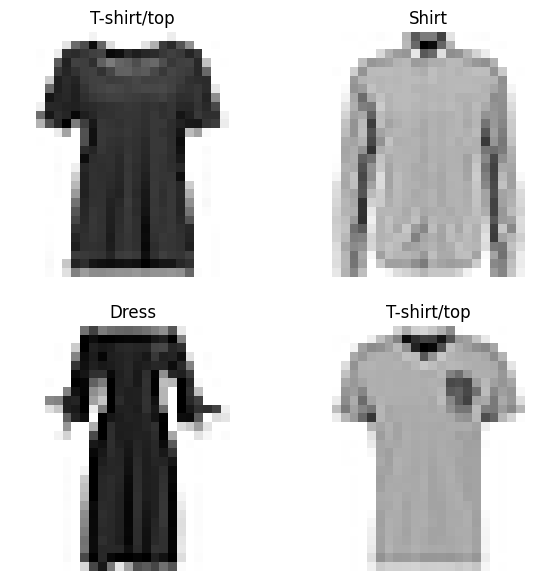

In [5]:
# Human interpretation of lables

index_of_choice = rng.uniform(shape=[], minval=0, maxval=len(train_data), dtype=tf.int32)
print(index_of_choice)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


plt.figure(figsize=(7, 7))

for i in range(4):
  ax = plt.subplot(2, 2, i+1)
  import random
  index_of_choice = random.randint(0, len(train_data))
  plt.imshow(train_data[index_of_choice], cmap=plt.cm.binary)
  plt.title(class_names[train_lables[index_of_choice]])
  plt.axis("off")


# plt.imshow(train_data[index_of_choice], cmap=plt.cm.binary)
# plt.title(class_names[train_lables[index_of_choice]])

What is the flatten layer?
CategoricalCrossentory() loss function vs sparseCategoricalCrossentory()

In [6]:
## Building the model
# input shape = (28, 28)
# output shpae = 10
# loss function = CategoricalCrossentropy

tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)), # Explicitly define the input layer
    tf.keras.layers.Flatten(), # No need to specify input_shape here, it's inferred from the Input layer
    # In the summary, (None, 784) means the batch size is flexible (None), and there are 784 features per sample.
    tf.keras.layers.Dense(12, activation="relu"),
    tf.keras.layers.Dense(12, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax") # Output layer for 10 classes
])

model_1.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

model_1.summary()
# Note on model.summary() output:
# - 'None' in the Output Shape indicates a variable batch size.
# - For the Flatten layer, (None, 784) means each input (28x28) is flattened to a vector of 784 elements.
# - Subsequent Dense layers show the output shape after processing, with 'None' for the batch size.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │         9,420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,706 (37.91 KB)

 Trainable params: 9,706 (37.91 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
non_norm_history = model_1.fit(train_data, train_lables, epochs=10, validation_data=(test_data, test_lables))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2960 - loss: 2.1028 - val_accuracy: 0.3057 - val_loss: 1.5845
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4155 - loss: 1.4055 - val_accuracy: 0.4195 - val_loss: 1.3270
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4773 - loss: 1.2585 - val_accuracy: 0.4778 - val_loss: 1.2153
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.5123 - loss: 1.1630 - val_accuracy: 0.5138 - val_loss: 1.1369
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.5286 - loss: 1.1189 - val_accuracy: 0.5259 - val_loss: 1.1126
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.5333 - loss: 1.1005 - val_accuracy: 0.5316 - val_loss: 1.1211
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5407 - loss: 1.0860 - val_accuracy: 0.5449 - val_loss: 1.0760
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5554 - loss: 1.0381 -

In [8]:
model_1.evaluate(test_data, test_lables)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5725 - loss: 1.0119


[1.0119034051895142, 0.5724999904632568]

In [9]:
train_data.min(), train_data.max()

(np.uint8(0), np.uint8(255))

In [10]:
train_data = train_data / 255.0
test_data = test_data / 255.0

In [11]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model_2.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"]
                )

norm_history = model_2.fit(train_data, train_lables, epochs=10, validation_data=(test_data, test_lables))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5144 - loss: 1.2185 - val_accuracy: 0.6494 - val_loss: 0.8633
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6852 - loss: 0.7881 - val_accuracy: 0.7076 - val_loss: 0.7542
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7274 - loss: 0.7160 - val_accuracy: 0.7338 - val_loss: 0.7093
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7455 - loss: 0.6800 - val_accuracy: 0.7444 - val_loss: 0.6844
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7556 - loss: 0.6566 - val_accuracy: 0.7503 - val_loss: 0.6707
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7606 - loss: 0.6439 - val_accuracy: 0.7523 - val_loss: 0.6646
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7642 - loss: 0.6362 - val_accuracy: 0.7550 - val_loss: 0.6609
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7668 - loss: 0.6307 - 

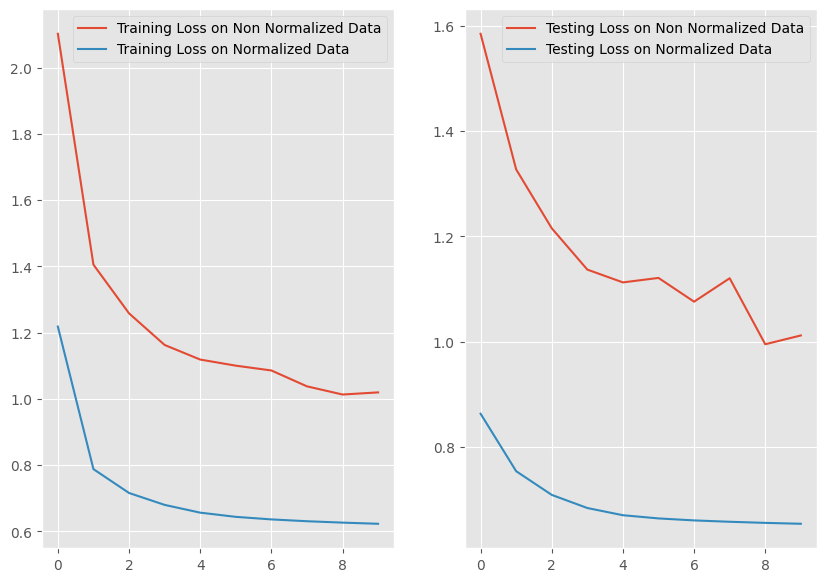

In [12]:
plt.style.use('ggplot')
plt.figure(figsize=(10, 7))

ax1 = plt.subplot(1, 2, 1)
ax1.plot(non_norm_history.history["loss"], label="Training Loss on Non Normalized Data")
ax1.plot(norm_history.history["loss"], label="Training Loss on Normalized Data")
plt.legend()
ax2 = plt.subplot(1, 2, 2)
ax2.plot(non_norm_history.history["val_loss"], label="Testing Loss on Non Normalized Data")
ax2.plot(norm_history.history["val_loss"], label="Testing Loss on Normalized Data")
plt.legend()
plt.show()

In [13]:
# Finding the ideal learning rate

tf.random.set_seed(42)

model_3 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model_3.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5)

lr_history = model_3.fit(train_data,
                         train_lables,
                         validation_data=(test_data, test_lables),
                         epochs=40,
                         callbacks=[lr_scheduler])

Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.2228 - loss: 2.0696 - val_accuracy: 0.3486 - val_loss: 1.8955 - learning_rate: 1.0000e-04
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3698 - loss: 1.7492 - val_accuracy: 0.3857 - val_loss: 1.6095 - learning_rate: 1.1220e-04
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4805 - loss: 1.4510 - val_accuracy: 0.5268 - val_loss: 1.3504 - learning_rate: 1.2589e-04
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5410 - loss: 1.2538 - val_accuracy: 0.5403 - val_loss: 1.2099 - learning_rate: 1.4125e-04
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5618 - loss: 1.1410 - val_accuracy: 0.5569 - val_loss: 1.1218 - learning_rate: 1.5849e-04
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5827 - loss: 1.0635 - val_accuracy: 0.5829 - val_loss: 1.0573 - learning_rate: 1.7783e-04
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/ste

In [14]:
model_3.evaluate(test_data, test_lables)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7946 - loss: 0.5927


[0.5927050113677979, 0.7946000099182129]

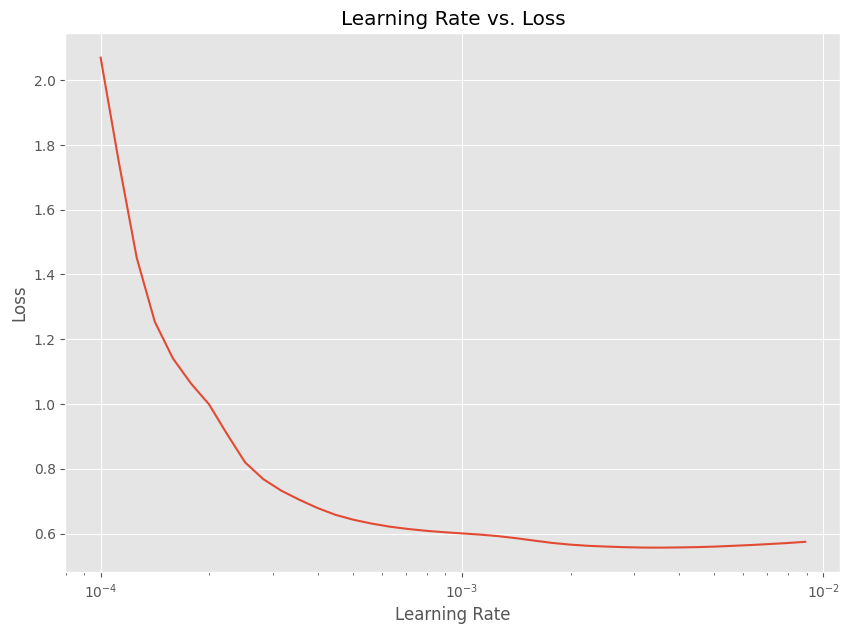

In [15]:
# Plotting the loss curve in log scale

plt.figure(figsize=(10, 7))
lrs = 1e-4 * (10 ** (tf.range(40)/20))
plt.semilogx(lrs, lr_history.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning Rate vs. Loss")
plt.show()

In [16]:
# Model 4 with ideal learning rate

model_4 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model_4.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])

model_4.fit(train_data, train_lables, epochs=10, validation_data=(test_data, test_lables))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.5735 - loss: 1.2266 - val_accuracy: 0.6643 - val_loss: 0.9021
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6833 - loss: 0.8134 - val_accuracy: 0.7114 - val_loss: 0.7488
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7581 - loss: 0.6629 - val_accuracy: 0.7644 - val_loss: 0.6584
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7754 - loss: 0.6096 - val_accuracy: 0.7723 - val_loss: 0.6311
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7823 - loss: 0.5857 - val_accuracy: 0.7765 - val_loss: 0.6166
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7873 - loss: 0.5714 - val_accuracy: 0.7804 - val_loss: 0.6075
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7923 - loss: 0.5609 - val_accuracy: 0.7847 - val_loss: 0.6025
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7964 - loss: 0.5527 - 

In [17]:
preds4 = model_4.predict(test_data)
model_4.evaluate(test_data, test_lables)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7927 - loss: 0.5884


[0.5883973240852356, 0.7926999926567078]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


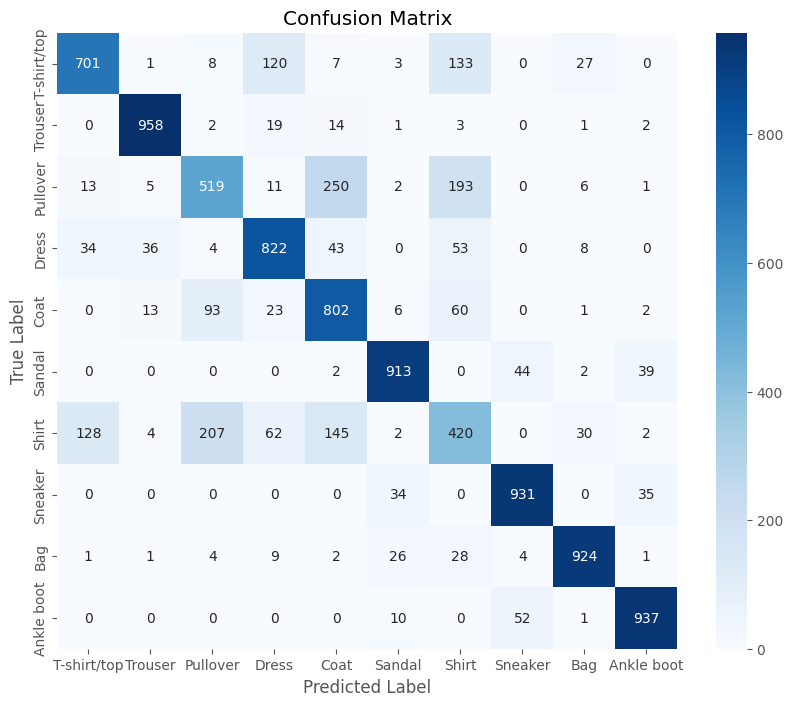

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
import tensorflow as tf # Ensure tf is imported for argmax

def make_confusion_matrix(y_true, y_pred_probs, class_names):
  """
  Generates and plots a confusion matrix for multi-class classification.

  Args:
    y_true: True labels.
    y_pred_probs: Predicted probabilities (output of softmax layer).
    class_names: List of class names.
  """
  # Convert prediction probabilities to class labels
  y_pred_labels = tf.argmax(y_pred_probs, axis=1).numpy()

  # Calculate the confusion matrix
  cm = confusion_matrix(y_true, y_pred_labels)

  # Plot the confusion matrix
  plt.figure(figsize=(10, 8))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=class_names, yticklabels=class_names)
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.show()

# Make predictions with model_4
y_pred_probs = model_4.predict(test_data)

# Call the function to plot the confusion matrix
make_confusion_matrix(test_lables, y_pred_probs, class_names)


Predict on same kind of data the model was trained for.

In [19]:
print(tf.round(preds4))

tf.Tensor(
[[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]], shape=(10000, 10), dtype=float32)


In [20]:
# Check Random Images from test data to predicting there type

def plot_random_image():
  import random
  index_of_choice = random.randint(0, len(test_data))
  plt.imshow(test_data[index_of_choice])
  plt.title(class_names[test_lables[index_of_choice]])
  plt.axis("off")

  # Print the predicted values of the test
  predicted_choice = tf.argmax(tf.round(preds4[index_of_choice]))
  print(f"Predicted Values: {class_names[predicted_choice]}")


examples = []
for i in range(40):
  import random
  index_of_choice = random.randint(0, len(test_data))
  true_choice = class_names[test_lables[index_of_choice]]
  predicted_choice = tf.argmax(tf.round(preds4[index_of_choice]))
  predicted_choice = class_names[predicted_choice]
  flag = "❌"
  if true_choice == predicted_choice:
    flag = "✅"
  examples.append([index_of_choice, true_choice, predicted_choice, flag])

import pandas as pd
df = pd.DataFrame(examples)
df

,0,1,2,3
0,4585,Shirt,T-shirt/top,❌
1,2810,Dress,Dress,✅
2,9737,T-shirt/top,T-shirt/top,✅
3,3392,Pullover,Coat,❌
4,6541,Sneaker,Sneaker,✅
5,9976,Sandal,Sandal,✅
6,964,Bag,Bag,✅
7,7622,Bag,Bag,✅
8,5222,Coat,Coat,✅
9,2388,Bag,Bag,✅


In [24]:
# What patterns is our model is learning?
# Getting the weights and biases

weights, biases = model_4.layers[1].get_weights()

weights, weights.shape, biases, biases.shape

(array([[-0.5432854 ,  0.5139247 , -0.08282918, -0.25027028],
        [-0.56702936,  0.30555165,  0.09209658,  0.10333239],
        [-0.662026  ,  0.8262038 ,  0.12661211,  0.11316597],
        ...,
        [ 0.0829922 , -0.03111348, -0.21264303,  0.73043525],
        [-0.41664457,  0.19395368,  0.09281685,  0.95890486],
        [-0.49903625,  0.36303195, -0.01530769,  0.23682447]],
       dtype=float32),
 (784, 4),
 array([ 0.21128581,  0.6527134 ,  0.2990104 , -0.5990244 ], dtype=float32),
 (4,))